# Eksperyment: Test

Test działania eksperymentów.

In [1]:
# === 1. Konfiguracja ===
datasets = {
    # # ======== KLASYFIKACJA - MNIST ========
    # "mnist_sigmoid": {
    #     "train_images": "../mnist/train-images.idx3-ubyte",
    #     "train_labels": "../mnist/train-labels.idx1-ubyte",
    #     "test_images": "../mnist/t10k-images.idx3-ubyte",
    #     "test_labels": "../mnist/t10k-labels.idx1-ubyte",
    #     "task": "multiclass",
    #     "losses": ["categorical_cross_entropy"],
    #     "activation": "sigmoid",
    #     "learning_rate": 0.05,
    #     "hidden_layers": [512],
    #     "epochs": [2000],
    #     "momentum": True,
    #     "adaptive_lr": True,
    # },
    # "mnist_sigmoid_warstwy": {
    #     "train_images": "../mnist/train-images.idx3-ubyte",
    #     "train_labels": "../mnist/train-labels.idx1-ubyte",
    #     "test_images": "../mnist/t10k-images.idx3-ubyte",
    #     "test_labels": "../mnist/t10k-labels.idx1-ubyte",
    #     "task": "multiclass",
    #     "losses": ["categorical_cross_entropy"],
    #     "activation": "sigmoid",
    #     "learning_rate": 0.05,
    #     "hidden_layers": [128, 128, 64],
    #     "epochs": [2000],
    #     "momentum": True,
    #     "adaptive_lr": True,
    # },
    "mnist_gelu": {
        "train_images": "../mnist/train-images.idx3-ubyte",
        "train_labels": "../mnist/train-labels.idx1-ubyte",
        "test_images": "../mnist/t10k-images.idx3-ubyte",
        "test_labels": "../mnist/t10k-labels.idx1-ubyte",
        "task": "multiclass",
        "losses": ["categorical_cross_entropy"],
        "activation": "gelu",
        "learning_rate": 0.05,
        "hidden_layers": [64, 64, 64, 64, 64],
        "epochs": [2000],
        "momentum": True,
        "adaptive_lr": True,
    },
}



=== Dataset: MNIST_GELU ===

>>> Loss=categorical_cross_entropy, Epochs=2000
epoch=   0  loss=2.30958721  acc=0.1427  lr=0.0500
epoch= 100  loss=0.67248649  acc=0.7885  lr=0.0452
epoch= 200  loss=0.34013800  acc=0.8994  lr=0.0409
epoch= 300  loss=0.27790778  acc=0.9171  lr=0.0370
epoch= 400  loss=0.24473886  acc=0.9268  lr=0.0335
epoch= 500  loss=0.22290790  acc=0.9332  lr=0.0303
epoch= 600  loss=0.20724618  acc=0.9381  lr=0.0274
epoch= 700  loss=0.19538584  acc=0.9417  lr=0.0248
epoch= 800  loss=0.18606172  acc=0.9444  lr=0.0225
epoch= 900  loss=0.17853348  acc=0.9469  lr=0.0203
epoch=1000  loss=0.17233490  acc=0.9484  lr=0.0184
epoch=1100  loss=0.16715440  acc=0.9500  lr=0.0166
epoch=1200  loss=0.16277374  acc=0.9511  lr=0.0151
epoch=1300  loss=0.15903440  acc=0.9521  lr=0.0136
epoch=1400  loss=0.15581777  acc=0.9529  lr=0.0123
epoch=1500  loss=0.15303294  acc=0.9539  lr=0.0111
epoch=1600  loss=0.15060887  acc=0.9545  lr=0.0101
epoch=1700  loss=0.14848907  acc=0.9551  lr=0.0091
epoc

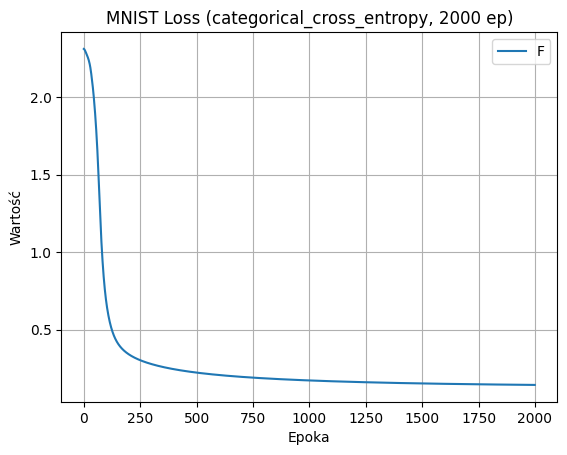

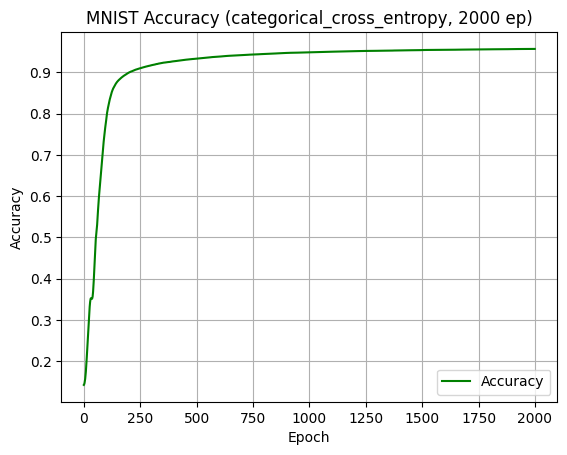

In [2]:
from mlp.mlp import MLP
from mlp.utils import (
    load_mnist_images,
    load_mnist_labels,
    plot_loss,
    plot_accuracy
)
import numpy as np

for dataset_name, cfg in datasets.items():
    print(f"\n=== Dataset: {dataset_name.upper()} ===")

    # --- Wczytanie danych MNIST ---
    X_train = load_mnist_images(cfg["train_images"])
    y_train = load_mnist_labels(cfg["train_labels"])
    X_test = load_mnist_images(cfg["test_images"])
    y_test = load_mnist_labels(cfg["test_labels"])

    n_inputs = X_train.shape[1]
    n_classes = 10

    for loss_name in cfg["losses"]:
        for epoch_count in cfg["epochs"]:
            print(f"\n>>> Loss={loss_name}, Epochs={epoch_count}")

            model = MLP(
                layer_sizes=[n_inputs, *cfg["hidden_layers"], n_classes],
                task=cfg["task"],
                activation=cfg["activation"],
                learning_rate=cfg["learning_rate"],
                seed=42,
                loss=loss_name,
                momentum=cfg.get("momentum", False),
                adaptive_lr=cfg.get("adaptive_lr", False),
                lr_decay=0.999
            )

            history, weight_hist, acc_hist = model.fit(
                X_train[:60000],
                y_train[:60000],
                epochs=epoch_count,
                verbose=True,
            )

            # --- Ewaluacja ---
            y_pred = model.predict(X_test)
            acc = np.mean(y_pred.ravel() == y_test.ravel())
            print(f"Test accuracy: {acc:.4f}")

            plot_loss(history, title=f"MNIST Loss ({loss_name}, {epoch_count} ep)")
            plot_accuracy(acc_hist, title=f"MNIST Accuracy ({loss_name}, {epoch_count} ep)")
